HIERARCHICAL CLUSTERING

 STEP 1: Loading Data
----------------------------------------
 Data loaded successfully!
   Shape: (1025, 13)

 STEP 2: Computing Linkage Matrix
----------------------------------------
 Linkage matrix computed
   Method: Ward (minimizes within-cluster variance)

 STEP 3: Plotting Dendrogram
----------------------------------------


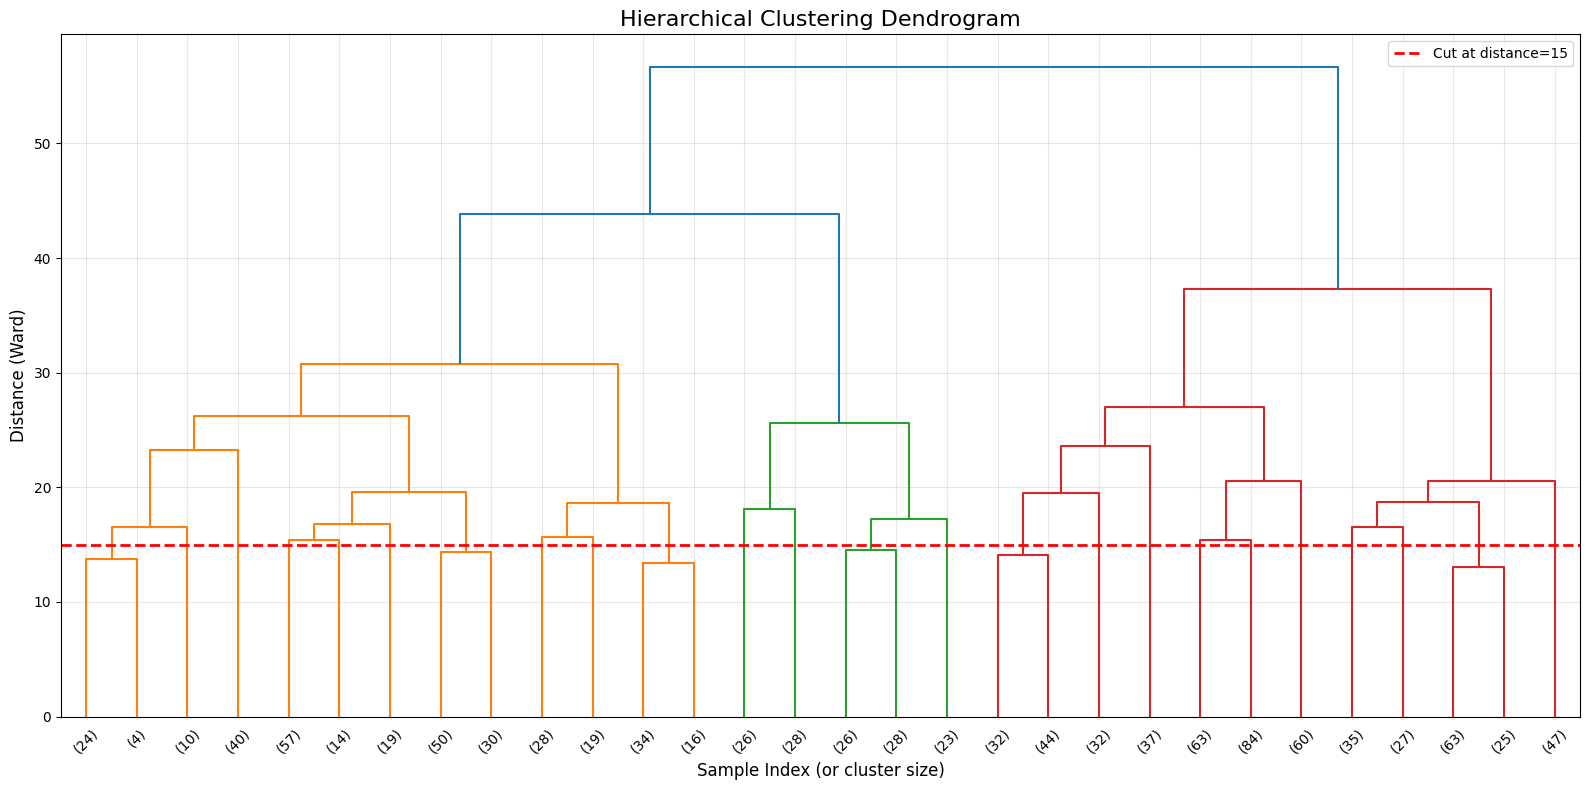

 Interpretation:
   - Vertical lines = clusters merged
   - Height = distance between merged clusters
   - Red line = where to cut to get clusters

 STEP 4: Finding Best Number of Clusters
----------------------------------------
   K=2: Silhouette Score=0.133
   K=3: Silhouette Score=0.153
   K=4: Silhouette Score=0.106
   K=5: Silhouette Score=0.111
   K=6: Silhouette Score=0.106
   K=7: Silhouette Score=0.113

 Best K: 3

 STEP 5: Cutting Dendrogram to Form Clusters
----------------------------------------

 Cluster Distribution:
   Cluster 1: 549 patients (53.6%)
   Cluster 2: 131 patients (12.8%)
   Cluster 3: 345 patients (33.7%)

 Silhouette Score: 0.153
 Adjusted Rand Index: 0.243

 STEP 6: Visualizing Hierarchical Clusters
----------------------------------------


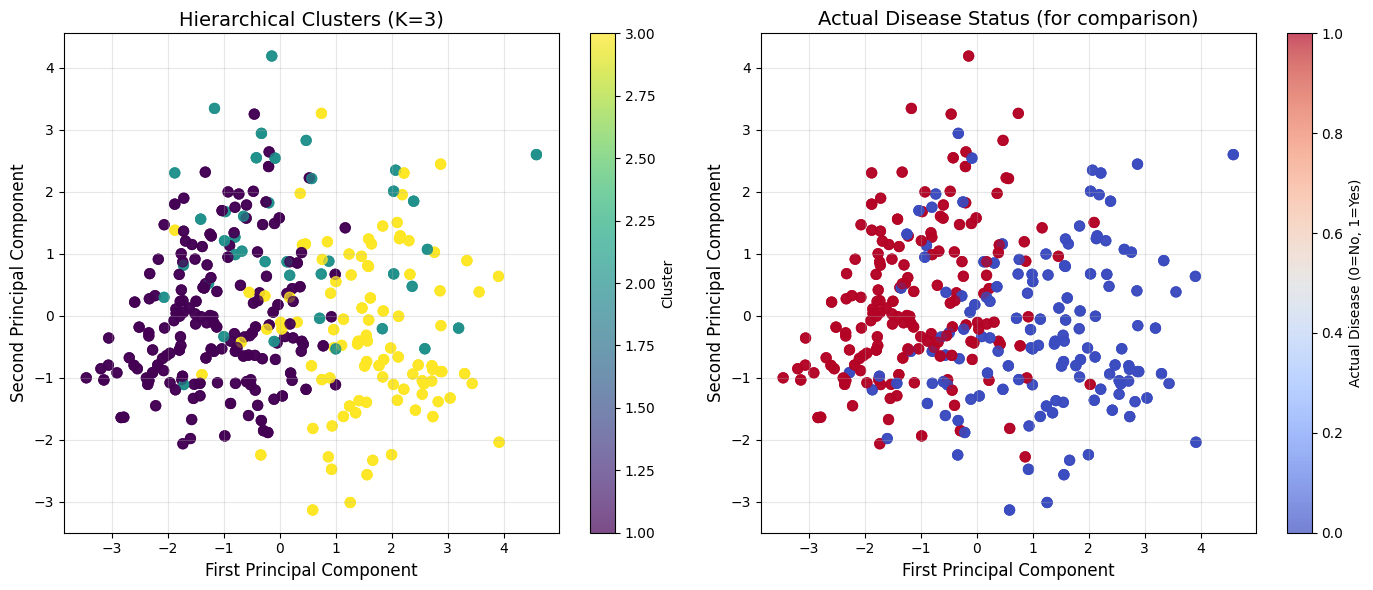


 STEP 7: Cluster Characteristics
----------------------------------------

 CLUSTER 1 (549 patients):
   Age: 51.8 years
   Heart Rate: 160.1 bpm
   Cholesterol: 239 mg/dl
   Disease Rate: 73.8%

 CLUSTER 2 (131 patients):
   Age: 57.1 years
   Heart Rate: 151.1 bpm
   Cholesterol: 252 mg/dl
   Disease Rate: 54.2%

 CLUSTER 3 (345 patients):
   Age: 57.6 years
   Heart Rate: 130.9 bpm
   Cholesterol: 254 mg/dl
   Disease Rate: 14.5%

 HIERARCHICAL CLUSTERING COMPLETE!


In [3]:
"""
TASK 2: HIERARCHICAL CLUSTERING
Creates a tree of clusters (dendrogram)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("HIERARCHICAL CLUSTERING")
print("="*60)

# ============================================
# STEP 1: Load Data
# ============================================
print("\n STEP 1: Loading Data")
print("-"*40)

X_scaled = pd.read_csv('X_scaled.csv')
df_original = pd.read_csv('heart.csv')
y_true = df_original['target']

print(f" Data loaded successfully!")
print(f"   Shape: {X_scaled.shape}")

# ============================================
# STEP 2: Compute Linkage Matrix
# ============================================
print("\n STEP 2: Computing Linkage Matrix")
print("-"*40)

# Using 'ward' method (minimizes variance within clusters)
linked = linkage(X_scaled, method='ward')

print(f" Linkage matrix computed")
print(f"   Method: Ward (minimizes within-cluster variance)")

# ============================================
# STEP 3: Plot Dendrogram
# ============================================
print("\n STEP 3: Plotting Dendrogram")
print("-"*40)

plt.figure(figsize=(16, 8))

# Plot full dendrogram (truncated for readability)
dendrogram(linked, 
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='lastp',
           p=30)  # Show last 30 clusters

plt.title('Hierarchical Clustering Dendrogram', fontsize=16)
plt.xlabel('Sample Index (or cluster size)', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.axhline(y=15, color='red', linestyle='--', linewidth=2, label='Cut at distance=15')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

print(" Interpretation:")
print("   - Vertical lines = clusters merged")
print("   - Height = distance between merged clusters")
print("   - Red line = where to cut to get clusters")

# ============================================
# STEP 4: Find Best Number of Clusters
# ============================================
print("\n STEP 4: Finding Best Number of Clusters")
print("-"*40)

silhouette_scores = []
for n_clusters in range(2, 8):
    clusters = fcluster(linked, n_clusters, criterion='maxclust')
    sil_score = silhouette_score(X_scaled, clusters)
    silhouette_scores.append(sil_score)
    print(f"   K={n_clusters}: Silhouette Score={sil_score:.3f}")

best_k_hc = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
print(f"\n Best K: {best_k_hc}")

# ============================================
# STEP 5: Cut Dendrogram to Get Clusters
# ============================================
print("\n STEP 5: Cutting Dendrogram to Form Clusters")
print("-"*40)

clusters = fcluster(linked, best_k_hc, criterion='maxclust')

print(f"\n Cluster Distribution:")
for i in range(1, best_k_hc + 1):
    count = (clusters == i).sum()
    print(f"   Cluster {i}: {count} patients ({count/len(clusters)*100:.1f}%)")

# Calculate metrics
sil_score = silhouette_score(X_scaled, clusters)
ari = adjusted_rand_score(y_true, clusters)

print(f"\n Silhouette Score: {sil_score:.3f}")
print(f" Adjusted Rand Index: {ari:.3f}")

# ============================================
# STEP 6: Visualize Clusters
# ============================================
print("\n STEP 6: Visualizing Hierarchical Clusters")
print("-"*40)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# Plot 1: Hierarchical Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title(f'Hierarchical Clusters (K={best_k_hc})', fontsize=14)
plt.grid(True, alpha=0.3)

# Plot 2: Actual Disease Status
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(scatter, label='Actual Disease (0=No, 1=Yes)')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('Actual Disease Status (for comparison)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hierarchical_clusters.png', dpi=150)
plt.show()

# ============================================
# STEP 7: Cluster Interpretation
# ============================================
print("\n STEP 7: Cluster Characteristics")
print("-"*40)

for i in range(1, best_k_hc + 1):
    cluster_indices = (clusters == i)
    cluster_data = df_original[cluster_indices]
    
    print(f"\n CLUSTER {i} ({len(cluster_data)} patients):")
    print(f"   Age: {cluster_data['age'].mean():.1f} years")
    print(f"   Heart Rate: {cluster_data['thalach'].mean():.1f} bpm")
    print(f"   Cholesterol: {cluster_data['chol'].mean():.0f} mg/dl")
    print(f"   Disease Rate: {cluster_data['target'].mean()*100:.1f}%")

print("\n" + "="*60)
print(" HIERARCHICAL CLUSTERING COMPLETE!")
print("="*60)